# Megatutorial 3: Transfer Learning

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import image_dataset_from_directory
from matplotlib import pyplot as plt
from PIL import Image
from numpy import array

## Load Data

In [24]:
training_data = image_dataset_from_directory(
    "../data",
    image_size=(224, 224),
    batch_size=3
)

Found 12 files belonging to 3 classes.


## Model Setup

In [28]:
model = Sequential()
model.add(Input(shape=[224, 224, 3], name="Input"))
model.add(VGG16(include_top=False, weights="imagenet", name="Feature_Extractor"))
model.add(Flatten(name="Flatten"))
model.add(Dense(512, activation="relu", name="Dense_1"))
model.add(Dense(3, activation="softmax", name="Output"))

model.layers[0].trainable = False

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Feature_Extractor (Functional)  │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,561,795 (105.14 MB)

 Trainable params: 12,847,107 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train Model

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

In [30]:
log = model.fit(training_data, epochs=10, verbose=1)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - loss: 109.5244
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 89.7299
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 51.6226
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 7.5978 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 11.7945
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 12.2238
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.0000e+00
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 0.0000e+00
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0000e+00
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0024  


Text(0, 0.5, 'loss')

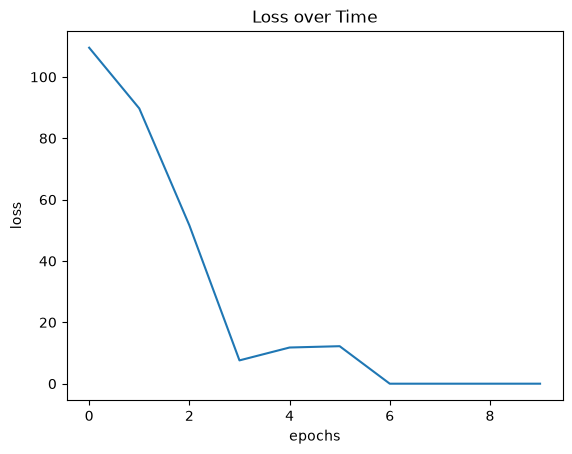

In [34]:
plt.plot(log.history["loss"])
plt.title("Loss over Time")
plt.xlabel("epochs")
plt.ylabel("loss")

## Model Use

In [45]:
modelimg = plt.imread("../data/free/image_01.jpeg")

img_pil = Image.fromarray(modelimg)
img_arr = array(img_pil.resize((224, 224)))
img_arr = img_arr.reshape(1, 224, 224, 3)
img_arr = preprocess_input(img_arr)
model.predict(img_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


array([[0., 1., 0.]], dtype=float32)